/tmp/ipykernel_8074/2608595753.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))


tensor([[ 66,  65,  65,  ..., 138, 139, 139],
        [ 65, 141, 142,  ...,  74, 137, 138]], dtype=torch.int32)
Numero di nodi isolati:  0
Shape di data:  Data(x=[163, 200], edge_index=[2, 660], y=[163], name=[163])
  Statistic      Value
0      Mean   0.122145
1   Std Dev   4.152881
2       Min -26.557415
3       Max  28.152184
4    Median   0.056933


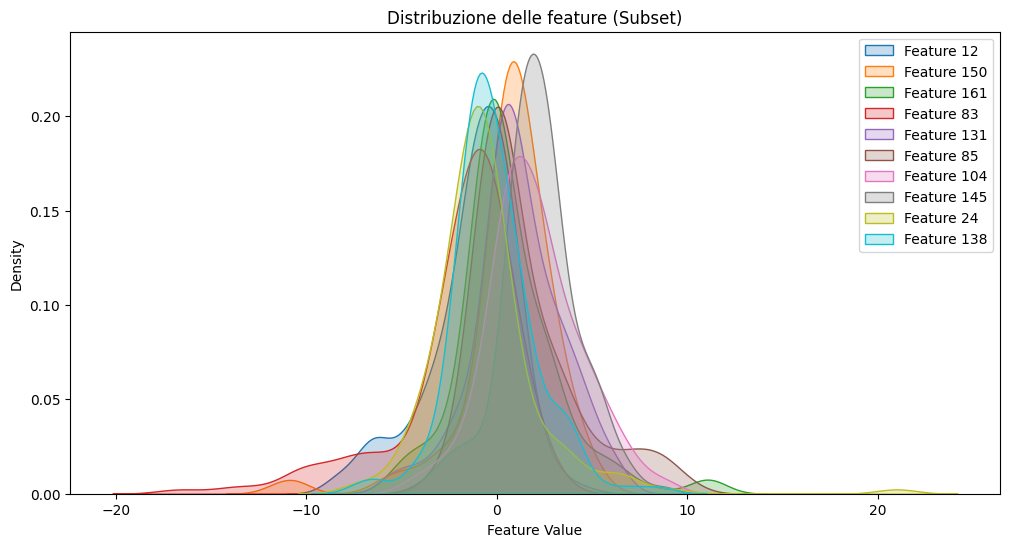

In [ ]:
# TODOs:
# 1. Controllare che avere proteine in comune duplicate non corrompa il training...dopo tutto se passo la stessa proteina due volte al modello e gli do risposte diverse potrebbe confondersi....
# 2. Valutare la reimmissione delle componenti connessi più piccole


import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
import pickle

nodes_df = pd.read_csv("./pre_processing_output/duplicated_nodes_main_components.csv")  # Dataset con nodi (proteine)
edges_df = pd.read_csv("./pre_processing_output/duplicated_edges_main_components.csv")  # Dataset con interazioni proteina-proteina
with open('./pre_processing_output/common_duplicated_protein_id.pkl', 'rb') as f:
    common_duplicated_protein_ids = pickle.load(f)

nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.float))

# Aggiungo nodi al grafo
G = nx.Graph()
for _, row in nodes_df.iterrows():
    num_id = int(row['num_id'])
    G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))

edges_df['num_id_1'] = edges_df['num_id_1'].astype(int)
edges_df['num_id_2'] = edges_df['num_id_2'].astype(int)
edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.int)

print(edges)

# Per visualizzazione debug
G.add_edges_from(zip(edges_df['num_id_1'], edges_df['num_id_2']))

print("Numero di nodi isolati: ", len(list(nx.isolates(G))))

data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    edge_index=edges,  # Edge list
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes]),
    name= [G.nodes[n]['name'] for n in G.nodes]
)

print("Shape di data: ", data)

# CALCOLO STATISTICHE FEATURE

import torch
import numpy as np
import pandas as pd

feature_values = data.x.cpu().numpy()

# Calcolare statistiche comuni a tutte le feature
mean_value = np.mean(feature_values)  # Media globale
std_value = np.std(feature_values)    # Deviazione standard globale
min_value = np.min(feature_values)    # Valore minimo globale
max_value = np.max(feature_values)    # Valore massimo globale
median_value = np.median(feature_values)  # Mediana globale

global_stats = pd.DataFrame({
    "Statistic": ["Mean", "Std Dev", "Min", "Max", "Median"],
    "Value": [mean_value, std_value, min_value, max_value, median_value]
})

print(global_stats)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

num_features_to_plot = min(10, feature_values.shape[1])
selected_features = np.random.choice(feature_values.shape[1], num_features_to_plot, replace=False)

plt.figure(figsize=(12, 6))
for feat_idx in selected_features:
    sns.kdeplot(feature_values[:, feat_idx], label=f'Feature {feat_idx}', fill=True)

plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.title("Distribuzione delle feature (Subset)")
plt.legend()
plt.show()



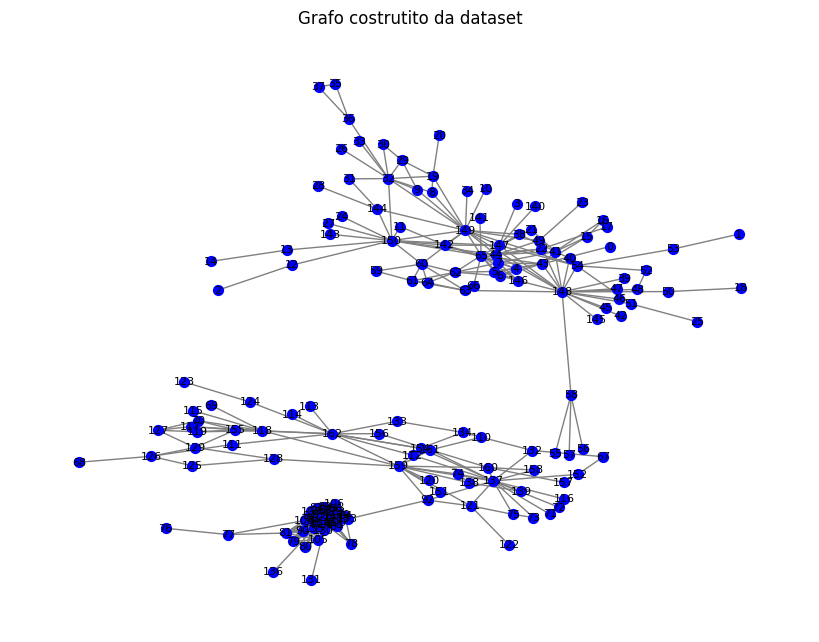

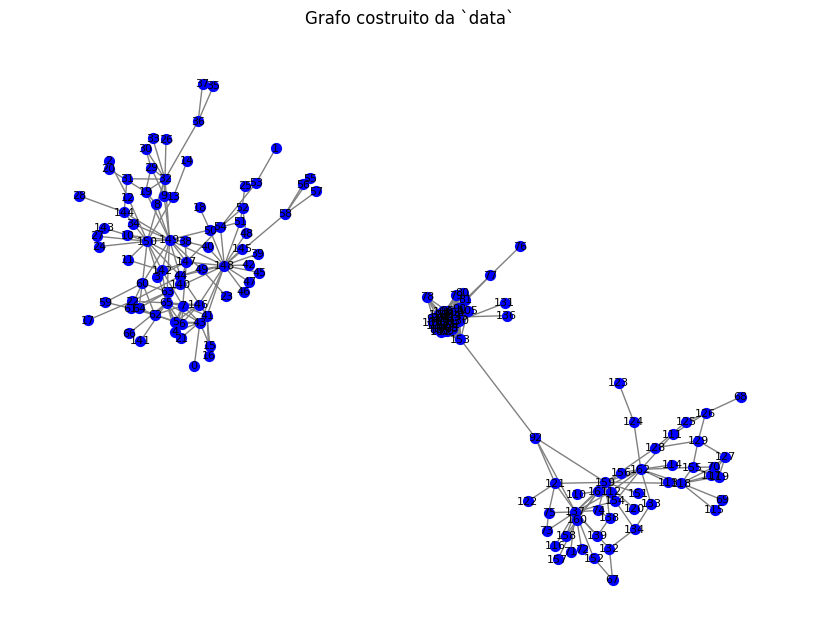

In [97]:
# CELLA DI DEBUG
import matplotlib.pyplot as plt
import networkx as nx

# PLOT GRAFO PRE DATA
plt.figure(figsize=(8, 6))  # Imposta la dimensione della figura
nx.draw(G, with_labels=True, node_size=50, font_size=8, edge_color="gray", node_color="blue")
plt.title("Grafo costrutito da dataset")
plt.show()
# PLOT DATO POST DATA

G_temp = nx.Graph()
G_temp.add_nodes_from(range(data.x.shape[0]))
edges = data.edge_index.cpu().numpy()
G_temp.add_edges_from(zip(edges[0], edges[1]))

plt.figure(figsize=(8, 6))
nx.draw(G_temp, with_labels=True, node_size=50, font_size=8, edge_color="gray", node_color="blue")
plt.title("Grafo costruito da `data`")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, dropout=0):
        super(GCN, self).__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)

        self.dropout = dropout
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.sigmoid(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = torch.sigmoid(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        return x.view(-1)  # Output logits
    
    def train_model(self, data, optimizer, criterion, epochs=200, patience=10):
        self.train()
        loss_values = []
        val_loss_values = []
        best_val_loss = float('inf')
        patience_counter = 0

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        for epoch in range(epochs):
            optimizer.zero_grad()
            out = self.forward(data.x, data.edge_index)
            train_loss = criterion(out[data.train_mask], data.y[data.train_mask].float())
            train_loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                val_out = self.forward(data.x, data.edge_index)
                val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask].float())
            self.train()

            loss_values.append(train_loss.item())
            val_loss_values.append(val_loss.item())

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        plt.figure()
        plt.plot(range(len(loss_values)), loss_values, label='Training Loss')
        plt.plot(range(len(val_loss_values)), val_loss_values, label='Validation Loss', linestyle='dashed')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training & Validation Loss Curve')
        plt.legend()
        plt.show()
    
    def k_fold_cross_validation(self, data, k=5, epochs=100, learning_rate=0.001, patience=10):
        """
        Questa funzione imposta un k-fold cross validation stratificato assicurandosi di avere le proteine
        in comune sempre nel test set (sarebbe un data leakage altrimenti).
        Esegue i k training e stampa le metriche di valutazione, la media di queste ed il miglior modello allenato.
        """
        kf = StratifiedKFold(n_splits=k, shuffle=True)
        indices = np.arange(data.x.shape[0])
        common_proteins_mask = np.array(["_AD" in name or "_PD" in name for name in data.name])
        best_model = None
        best_f1 = 0
        acc_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
        best_fold_metrics = {}
        best_cm = None

        for fold, (train_idx, val_idx) in enumerate(kf.split(data.x[~common_proteins_mask], data.y[~common_proteins_mask].cpu().numpy())):
            print(f"\n🔹 Fold {fold+1}/{k}")
            train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            val_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            
            # Aggiungi le proteine comuni al training set
            train_mask[common_proteins_mask] = True
            train_mask[train_idx] = True
            val_mask[val_idx] = True
            
            data.train_mask = train_mask
            data.val_mask = val_mask
            data.test_mask = ~train_mask

            model = GCN(in_channels=self.conv1.in_channels, 
                        hidden_channels=self.conv2.out_channels, 
                        out_channels=self.conv3.out_channels, 
                        dropout=self.dropout)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)
            criterion = torch.nn.BCEWithLogitsLoss()
            model.train_model(data, optimizer, criterion, epochs, patience)

            model.eval()
            with torch.no_grad():
                out = model(data.x, data.edge_index)
                out = torch.sigmoid(out)
                pred = (out[val_mask] > 0.5).int()
                y_true = data.y[val_mask].cpu().numpy()
                y_pred = pred.cpu().numpy()

                acc = accuracy_score(y_true, y_pred)
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                cm = confusion_matrix(y_true, y_pred)

                acc_scores.append(acc)
                precision_scores.append(precision)
                recall_scores.append(recall)
                f1_scores.append(f1)

                print(f"Accuracy: {acc:.4f}")
                print(f"Precision: {precision:.4f}")
                print(f"Recall: {recall:.4f}")
                print(f"F1-Score: {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model
                    best_fold_metrics = {
                        "Accuracy": acc,
                        "Precision": precision,
                        "Recall": recall,
                        "F1-Score": f1
                    }
                    best_cm = cm

        print("\n📊 **Statistiche medie della K-Fold Cross Validation**")
        print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
        print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
        print(f"Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
        print(f"F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
        
        return best_model


In [99]:
# Vecchio metodo di training

"""

# Train-test split e addestramento
from torch.optim import Adam

num_nodes = data.x.shape[0]
all_indices = torch.arange(num_nodes)

# Identifica gli indici delle proteine in comune
data_node_ids = list(G.nodes)  # Lista degli ID numerici delle proteine nel dataset
common_protein_indices = torch.tensor([data_node_ids.index(n) for n in common_duplicated_protein_ids if n in data_node_ids], dtype=torch.long)

# Identifica le proteine non in comune
non_common_indices = torch.tensor([idx for idx in all_indices if idx not in common_protein_indices], dtype=torch.long)

# Shuffle degli indici non comuni e split 70%-30%
num_non_common = len(non_common_indices)
num_train = int(0.8 * num_non_common)
perm = torch.randperm(num_non_common)
train_non_common = non_common_indices[perm[:num_train]]
test_non_common = non_common_indices[perm[num_train:]]

# Creazione delle maschere
train_indices = torch.cat((common_protein_indices, train_non_common))
test_indices = test_non_common

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_indices] = True
test_mask[test_indices] = True

data.train_mask = train_mask
data.test_mask = test_mask

# Inizializzazione e addestramento del modello
model = GCN(in_channels=data.x.shape[1], hidden_channels=64, out_channels=1)
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

model.train_model(data, criterion=nn.BCEWithLogitsLoss(), optimizer=optimizer, epochs=1000)
"""

'\n\n# Train-test split e addestramento\nfrom torch.optim import Adam\n\nnum_nodes = data.x.shape[0]\nall_indices = torch.arange(num_nodes)\n\n# Identifica gli indici delle proteine in comune\ndata_node_ids = list(G.nodes)  # Lista degli ID numerici delle proteine nel dataset\ncommon_protein_indices = torch.tensor([data_node_ids.index(n) for n in common_duplicated_protein_ids if n in data_node_ids], dtype=torch.long)\n\n# Identifica le proteine non in comune\nnon_common_indices = torch.tensor([idx for idx in all_indices if idx not in common_protein_indices], dtype=torch.long)\n\n# Shuffle degli indici non comuni e split 70%-30%\nnum_non_common = len(non_common_indices)\nnum_train = int(0.8 * num_non_common)\nperm = torch.randperm(num_non_common)\ntrain_non_common = non_common_indices[perm[:num_train]]\ntest_non_common = non_common_indices[perm[num_train:]]\n\n# Creazione delle maschere\ntrain_indices = torch.cat((common_protein_indices, train_non_common))\ntest_indices = test_non_commo


🔹 Fold 1/5
Epoch 0, Train Loss: 0.7245, Val Loss: 0.7049, LR: 0.001000
Epoch 10, Train Loss: 0.5762, Val Loss: 0.5728, LR: 0.001000
Epoch 20, Train Loss: 0.4715, Val Loss: 0.4848, LR: 0.001000
Epoch 30, Train Loss: 0.3694, Val Loss: 0.4083, LR: 0.001000
Epoch 40, Train Loss: 0.2761, Val Loss: 0.3460, LR: 0.001000


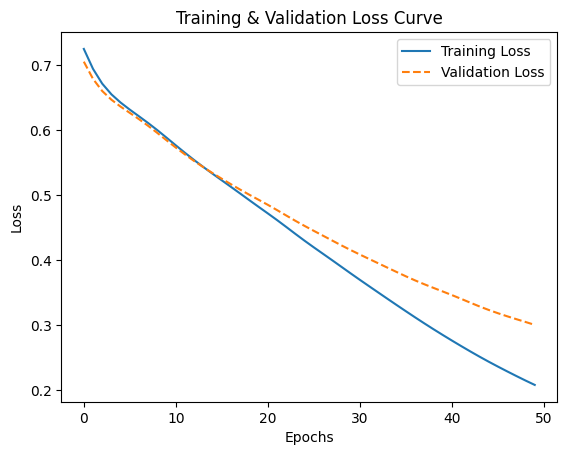

Accuracy: 0.8571
Precision: 0.8125
Recall: 0.9286
F1-Score: 0.8667

🔹 Fold 2/5
Epoch 0, Train Loss: 0.6808, Val Loss: 0.6521, LR: 0.001000
Epoch 10, Train Loss: 0.5256, Val Loss: 0.5355, LR: 0.001000
Epoch 20, Train Loss: 0.4324, Val Loss: 0.4421, LR: 0.001000
Epoch 30, Train Loss: 0.3424, Val Loss: 0.3686, LR: 0.001000
Epoch 40, Train Loss: 0.2546, Val Loss: 0.3048, LR: 0.001000


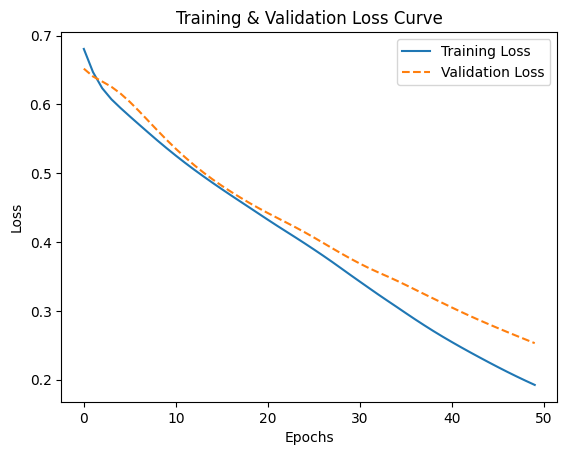

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

🔹 Fold 3/5
Epoch 0, Train Loss: 0.7214, Val Loss: 0.6786, LR: 0.001000
Epoch 10, Train Loss: 0.5504, Val Loss: 0.4868, LR: 0.001000
Epoch 20, Train Loss: 0.4516, Val Loss: 0.3858, LR: 0.001000
Epoch 30, Train Loss: 0.3539, Val Loss: 0.2966, LR: 0.001000
Epoch 40, Train Loss: 0.2677, Val Loss: 0.2248, LR: 0.001000


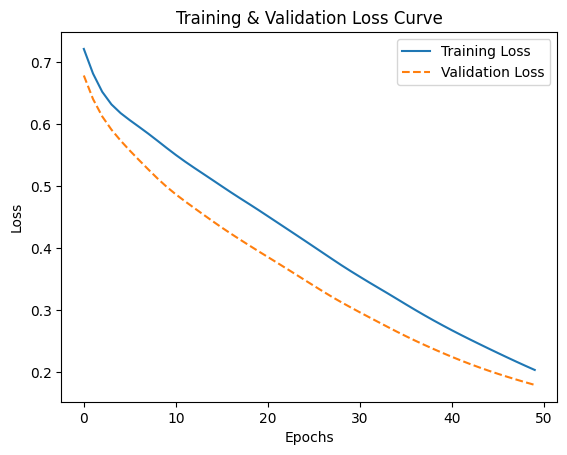

Accuracy: 0.9643
Precision: 1.0000
Recall: 0.9333
F1-Score: 0.9655

🔹 Fold 4/5
Epoch 0, Train Loss: 0.7155, Val Loss: 0.6709, LR: 0.001000
Epoch 10, Train Loss: 0.5685, Val Loss: 0.5428, LR: 0.001000
Epoch 20, Train Loss: 0.4717, Val Loss: 0.4700, LR: 0.001000
Epoch 30, Train Loss: 0.3804, Val Loss: 0.4044, LR: 0.001000
Epoch 40, Train Loss: 0.2936, Val Loss: 0.3440, LR: 0.001000


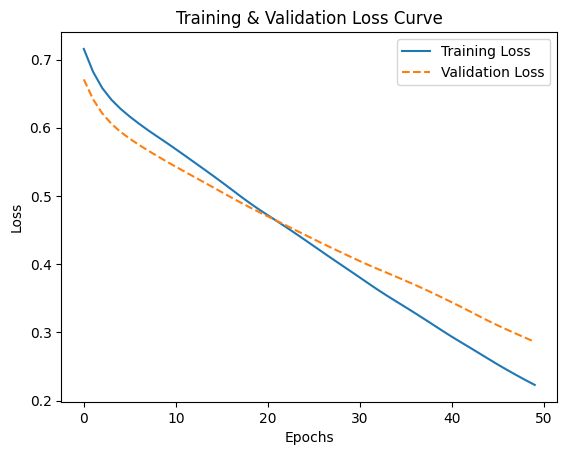

Accuracy: 0.9643
Precision: 1.0000
Recall: 0.9333
F1-Score: 0.9655

🔹 Fold 5/5
Epoch 0, Train Loss: 0.8409, Val Loss: 0.7677, LR: 0.001000
Epoch 10, Train Loss: 0.6086, Val Loss: 0.5907, LR: 0.001000
Epoch 20, Train Loss: 0.5286, Val Loss: 0.4906, LR: 0.001000
Epoch 30, Train Loss: 0.4604, Val Loss: 0.4178, LR: 0.001000
Epoch 40, Train Loss: 0.3845, Val Loss: 0.3489, LR: 0.001000


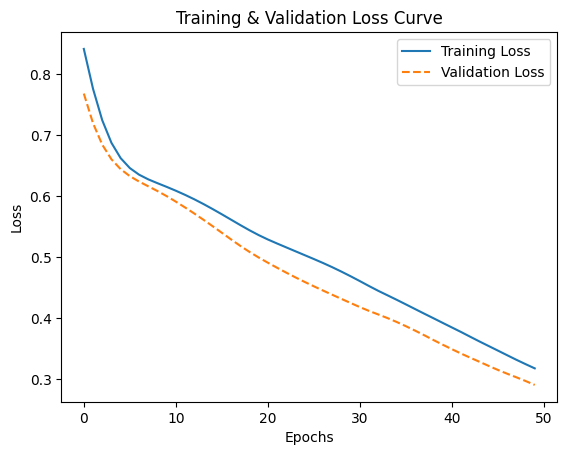

Accuracy: 0.9643
Precision: 0.9375
Recall: 1.0000
F1-Score: 0.9677

📊 **Statistiche medie della K-Fold Cross Validation**
Accuracy: 0.9500 ± 0.0484
Precision: 0.9500 ± 0.0729
Recall: 0.9590 ± 0.0335
F1-Score: 0.9531 ± 0.0452


In [100]:
from torch.optim import Adam

LR = 0.001

model = GCN(in_channels=data.x.shape[1], hidden_channels=64, out_channels=1, dropout=0)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=5e-4)

best = model.k_fold_cross_validation(data, epochs=50, learning_rate=LR, patience=10)